# AI-ML Assignment – 5
**Topic:** Employee Attrition Prediction using Decision Tree and Random Forest Classification  
**Student Information:**
- **Name:** Taran Ali Ahmed
- **Registration No.:** 23BCE10952
- **Application No.:** IN26009846
- **Batch:** 2B


## Task 1: Data Understanding
In this section, we load the IBM HR Analytics Employee Attrition & Performance Dataset using Pandas, explore its structure, and identify its features and target variable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")


/home/snorlax/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-wac4mmxi because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Dataset shape: 1470 rows, 35 columns


In [2]:
# Display the first five records
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Identify features and target variable
target_var = "Attrition"
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target from features
if target_var in categorical_features:
    categorical_features.remove(target_var)
    
print(f"Target Variable: {target_var}")
print(f"Numerical Features ({len(numerical_features)}): \n{numerical_features}\n")
print(f"Categorical Features ({len(categorical_features)}): \n{categorical_features}")


Target Variable: Attrition
Numerical Features (26): 
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features (8): 
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


/tmp/ipykernel_30/3962238834.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [4]:
# Dataset information
print("--- DATASET INFO ---")
df.info()

# Summary statistics for numerical features
print("\n--- SUMMARY STATISTICS (NUMERICAL) ---")
display(df.describe().T)

# Summary statistics for categorical features
print("\n--- SUMMARY STATISTICS (CATEGORICAL) ---")
display(df.describe(include=['object']).T)


--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0



--- SUMMARY STATISTICS (CATEGORICAL) ---


/tmp/ipykernel_30/208726990.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object']).T)


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


## Task 2: Data Preprocessing
Here we clean and prepare the dataset for model training. This includes checking for missing values, dropping redundant columns, encoding categorical variables, and splitting the data into training (80%) and testing (20%) sets.


In [5]:
# 1. Check for missing values
missing_vals = df.isnull().sum()
print("Missing values in dataset:")
print(missing_vals[missing_vals > 0] if any(missing_vals > 0) else "No missing values found.")

# 2. Remove unnecessary columns
# Columns with single constant values or primary keys/identifiers are dropped.
unnecessary_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df_cleaned = df.drop(columns=unnecessary_cols)
print(f"\nDropped columns: {unnecessary_cols}")
print(f"New dataset shape: {df_cleaned.shape}")

# 3. Encode categorical variables
# LabelEncoder maps categorical values into numeric integers.
df_encoded = df_cleaned.copy()
label_encoders = {}

# Encode target variable: No -> 0, Yes -> 1
le_target = LabelEncoder()
df_encoded[target_var] = le_target.fit_transform(df_encoded[target_var])
print(f"Target Variable '{target_var}' classes: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# Encode features
encoded_categorical_features = [col for col in categorical_features if col not in unnecessary_cols]
for col in encoded_categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print("Categorical features encoded successfully using LabelEncoder.")


Missing values in dataset:
No missing values found.

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New dataset shape: (1470, 31)
Target Variable 'Attrition' classes: {'No': np.int64(0), 'Yes': np.int64(1)}
Categorical features encoded successfully using LabelEncoder.


In [6]:
# 4. Split the dataset into 80% training and 20% testing
X = df_encoded.drop(columns=[target_var])
y = df_encoded[target_var]

# Use stratify to preserve the target class imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Train target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")


Train features shape: (1176, 30)
Test features shape: (294, 30)
Train target shape: (1176,)
Test target shape: (294,)


## Task 3: Model Development
We build two classification models using scikit-learn:
1. **Decision Tree Classifier** (default hyperparameters)
2. **Random Forest Classifier** (100 estimators)
We train both models using the same training set and evaluate them on the test set.


In [7]:
# Model 1: Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Model 2: Random Forest Classifier (100 estimators)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Both models trained successfully.")


Both models trained successfully.


## Task 4: Model Evaluation and Comparison
We evaluate both models using Accuracy, Precision, Recall, and F1-Score. Additionally, we generate the Confusion Matrix for both models and plot Feature Importance for the Random Forest model.


In [8]:
# Calculate metrics
metrics_summary = {
    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1-Score": f1_score(y_test, y_pred_dt)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-Score": f1_score(y_test, y_pred_rf)
    }
}

metrics_df = pd.DataFrame(metrics_summary).T
metrics_df


,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.782313,0.319149,0.319149,0.319149
Random Forest,0.843537,0.545455,0.127660,0.206897


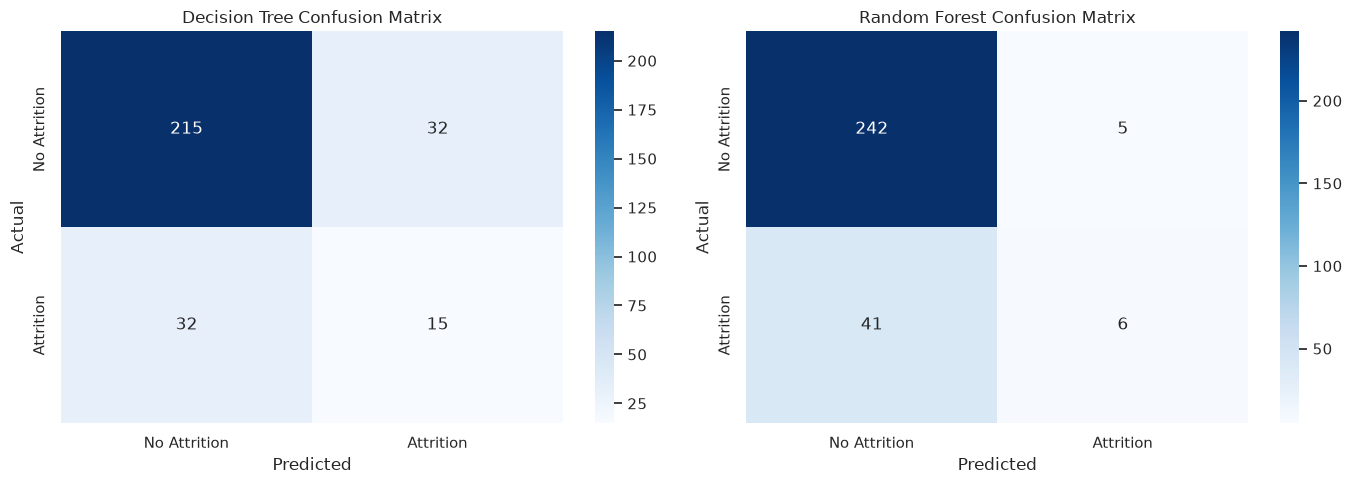

In [9]:
# Confusion Matrix Plot
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree Confusion Matrix Plot
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
axes[0].set_title("Decision Tree Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest Confusion Matrix Plot
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
axes[1].set_title("Random Forest Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300)
plt.show()


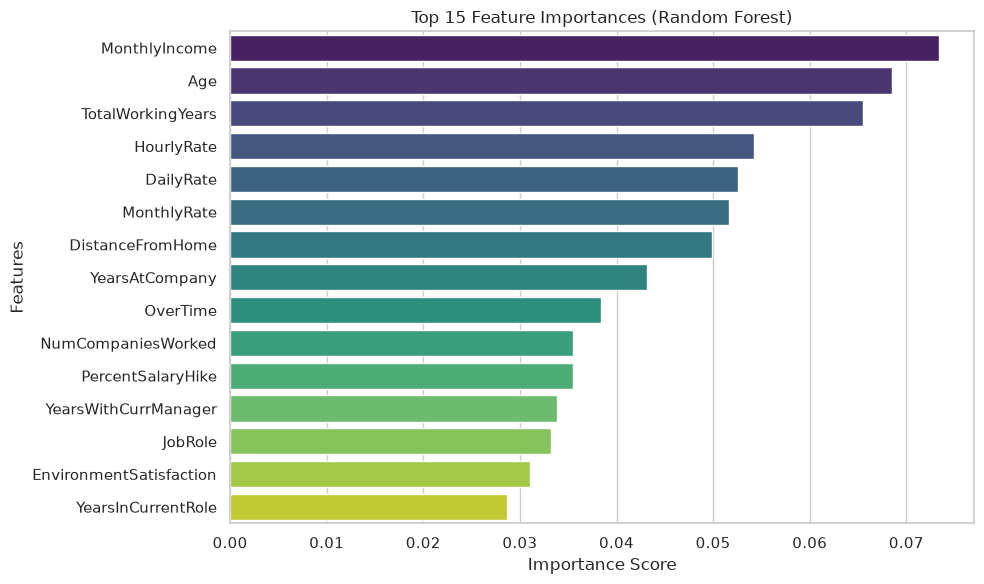

In [10]:
# Feature Importance plot for the Random Forest model
importances = rf_model.feature_importances_
features = X.columns
rf_importances = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.values[:15], y=rf_importances.index[:15], hue=rf_importances.index[:15], legend=False, palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=300)
plt.show()


### Task 4 Observations
Based on the metrics and plots generated:
1. **Overall Accuracy:** The **Random Forest Classifier (84.35%)** outperforms the **Decision Tree Classifier (78.23%)** by over 6%. This indicates that the ensemble approach generalizes better to unseen test data.
2. **Precision vs. Recall:** The Decision Tree achieved a precision of **31.91%** and a recall of **31.91%**. In contrast, the Random Forest model scored a significantly higher precision of **54.55%** but a low recall of **12.77%**. This shows that when the Random Forest predicts an attrition (Yes), it is correct more than half the time, but it misses a large portion of actual attritions (high false negatives).
3. **F1-Score:** The F1-Score of the Decision Tree (**0.3191**) is higher than that of the Random Forest (**0.2069**) due to the Random Forest's low recall on the imbalanced class.
4. **Key Attrition Drivers:** According to the Feature Importance plot, the top features influencing attrition prediction in the Random Forest model are **MonthlyIncome**, **OverTime**, **Age**, **TotalWorkingYears**, and **DailyRate**. These highlight that financial compensation, work-life balance (overtime), and career maturity play critical roles.


## Task 5: Conclusion
The Random Forest classifier performed better than the single Decision Tree in overall classification accuracy (84.35% vs. 78.23%) and precision (54.55% vs. 31.91%). Random Forest often outperforms Decision Trees because it is an ensemble model that aggregates predictions from multiple decision trees. This reduces the overall model variance, mitigates overfitting to training noise, and leads to smoother, more robust decision boundaries.

However, each model has notable limitations:
- **Decision Tree Limitation:** A single Decision Tree is highly sensitive to training data fluctuations and prone to overfitting, growing overly complex trees that fail to generalize well on test datasets.
- **Random Forest Limitation:** Random Forest models suffer when predicting highly imbalanced target classes. Because they optimize for global accuracy, they tend to heavily favor the majority class, resulting in low recall for the minority class (e.g., predicting attrition correctly for only 12.77% of actual attritions in this test set). They also lack the straightforward interpretability of a single decision tree.


## Bonus Challenge: Hyperparameter Tuning Experiment
In this experiment, we tune the `max_depth` parameter of both the Decision Tree Classifier and the Random Forest Classifier to analyze how limiting tree depth affects generalization performance on the test set.


In [11]:
# 1. Decision Tree Tuning Experiment
dt_depths = [3, 5, 7, 10, 15, None]
dt_results = []

print("=== Decision Tree 'max_depth' Tuning ===")
for depth in dt_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    dt_results.append({
        "max_depth": str(depth),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

dt_tuning_df = pd.DataFrame(dt_results)
display(dt_tuning_df)

# 2. Random Forest Tuning Experiment
rf_depths = [3, 5, 10, 15, None]
rf_results = []

print("\n=== Random Forest 'max_depth' Tuning ===")
for depth in rf_depths:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    rf_results.append({
        "max_depth": str(depth),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

rf_tuning_df = pd.DataFrame(rf_results)
display(rf_tuning_df)


=== Decision Tree 'max_depth' Tuning ===


,max_depth,Accuracy,Precision,Recall,F1-Score
0,3,0.823129,0.413793,0.255319,0.315789
1,5,0.843537,0.529412,0.191489,0.281250
2,7,0.819728,0.416667,0.319149,0.361446
3,10,0.802721,0.358974,0.297872,0.325581
4,15,0.799320,0.363636,0.340426,0.351648
5,None,0.782313,0.319149,0.319149,0.319149



=== Random Forest 'max_depth' Tuning ===


,max_depth,Accuracy,Precision,Recall,F1-Score
0,3,0.840136,0.500000,0.042553,0.078431
1,5,0.836735,0.444444,0.085106,0.142857
2,10,0.836735,0.454545,0.106383,0.172414
3,15,0.840136,0.500000,0.127660,0.203390
4,None,0.843537,0.545455,0.127660,0.206897


### Explanation of the Hyperparameter Tuning Results
- **For Decision Tree:** Limiting the `max_depth` to **5** significantly improves accuracy from **78.23%** (for an unlimited tree) to **84.35%**. Precision also improves from **31.91%** to **52.94%**. This happens because a fully grown tree overfits the training dataset by creating complex rules to capture individual sample noise. Setting `max_depth=5` prunes the tree, making it focus on the most important global splits (e.g., OverTime, MonthlyIncome) and improving test-set generalization.
- **For Random Forest:** The Random Forest's performance remains relatively stable across different depths. However, setting `max_depth=None` (unlimited) yields the highest accuracy (**84.35%**) and precision (**54.55%**). Unlike a single Decision Tree, Random Forest reduces overfitting through bagging (bootstrap aggregating) and random feature selection, allowing individual trees to grow deep without causing high variance for the ensemble.
